<center><h1>Time Series dan Forecasting</h1></center>

Sumber bacaan:
1. Hyndman, R.J., & Athanasopoulos, G. (2018) Forecasting: principles and practice, 2nd edition, OTexts: Melbourne, Australia. OTexts.com/fpp2

# A. Time Series

## A.0. Moving Average

Pengambilan data

In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv")
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


Plot data

<Axes: >

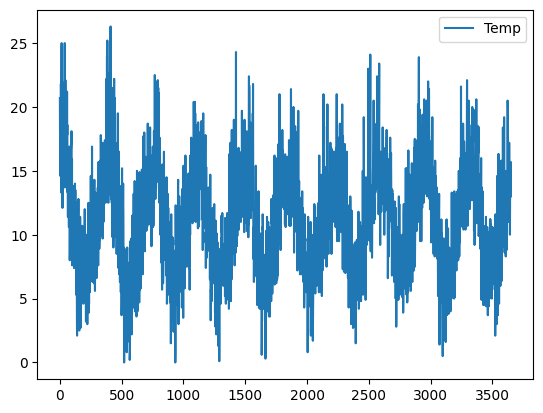

In [2]:
df.plot()

Moving average

In [3]:
# input lebar window
window_size = 100

# menggunakan metode rolling dari pandas
ma = df.rolling(window_size).mean()

# hapus nilai kosong
final_list = ma[window_size - 1:]

final_list.plot()

DataError: Cannot aggregate non-numeric type: object

## A.1. Time Series Decomposition

### A.1.0. Persiapan data

Membaca data dari https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv

In [ ]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv")
df.head()

Melihat tipe data

In [ ]:
df.info()

Mengubah tipe data

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

Menjadikan date sebagai index

In [ ]:
df = df.set_index('Date')
df.head()

Plot data

In [ ]:
df.plot()

### A.1.1. Decomposition

Install statsmodels versi terbaru

In [ ]:
# Harus install statsmodels versi terbaru (0.13.2)
!pip install statsmodels==0.13.2

Menggunakan Classical Decomposition

In [ ]:
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# model = additive atau multiplicative
# period = periode dari seasonal
df_sd = seasonal_decompose(x = df, model='additive', period=365, extrapolate_trend='freq')

fig,ax = plt.subplots(4,figsize=(12, 14))
ax[0].plot(df)
ax[1].plot(df_sd.seasonal)
ax[2].plot(df_sd.trend)
ax[3].plot(df_sd.resid)
ax[0].title.set_text('Raw')
ax[1].title.set_text('Seasonal')
ax[2].title.set_text('Trend')
ax[3].title.set_text('Residual')

Menggunakan STL

In [ ]:
from statsmodels.tsa.seasonal import STL

stl = STL(df,period=365)
df_stl = stl.fit()

fig,ax = plt.subplots(4,figsize=(12, 14))
ax[0].plot(df)
ax[1].plot(df_stl.seasonal)
ax[2].plot(df_stl.trend)
ax[3].plot(df_stl.resid)
ax[0].title.set_text('Raw')
ax[1].title.set_text('Seasonal')
ax[2].title.set_text('Trend')
ax[3].title.set_text('Residual')

## A.2. Time Series Stationarity

### A.2.0. Persiapan data

Pengambilan data

https://fred.stlouisfed.org/series/CBBTCUSD

In [ ]:
import pandas as pd

df = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23e1e9f0&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1168&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=CBBTCUSD&scale=left&cosd=2021-07-23&coed=2022-07-23&line_color=%234572a7&link_values=false&line_style=solid&mark_type=none&mw=3&lw=2&ost=-99999&oet=99999&mma=0&fml=a&fq=Daily%2C%207-Day&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2022-07-24&revision_date=2022-07-24&nd=2014-12-01")
df.head()

Mengubah tipe data

In [ ]:
df['DATE'] = pd.to_datetime(df['DATE'])
df.info()

Mengubah month menjadi index

In [ ]:
df = df.set_index('DATE')
df.head()

Plot data

In [ ]:
df.plot()

### A.2.1. Cek Stationary
Menggunakan ADF Test

In [ ]:
from statsmodels.tsa.stattools import adfuller

adf = adfuller(df)
print('ADF Statistic: %f' % adf[0])
print('p-value: %f' % adf[1])

### A.2.2. Membuat data menjadi stationary

Log Transformation

In [ ]:
import numpy as np
log_df = np.log(df)

fig,ax = plt.subplots(2,figsize=(12, 6))
ax[0].plot(df)
ax[1].plot(log_df)
ax[0].title.set_text('Raw')
ax[1].title.set_text('Log Raw')

Menguji hasil log transform dengan ADF

In [ ]:
resultadf = adfuller(log_df)
print('ADF Statistic: %f' % resultadf[0])
print('p-value: %f' % resultadf[1])

Box Cox Transformation

In [ ]:
from scipy.stats import boxcox

df_bc, fitted_lambda = boxcox(df['CBBTCUSD'])
print(fitted_lambda)

fig,ax = plt.subplots(2,figsize=(12, 6))
ax[0].plot(df)
ax[1].plot(df_bc)
ax[0].title.set_text('Raw')
ax[1].title.set_text('Box Cox')

Menguji hasil box cox transform dengan ADF

In [ ]:
resultadf = adfuller(df_bc)
print('ADF Statistic: %f' % resultadf[0])
print('p-value: %f' % resultadf[1])

First-Order Differencing

In [ ]:
df_diff = df.diff()

fig,ax = plt.subplots(2,figsize=(12, 6))
ax[0].plot(df)
ax[1].plot(df_diff)
ax[0].title.set_text('Raw')
ax[1].title.set_text('First-Order Difference')

Menguji hasil first-order differencing dengan ADF

In [ ]:
# mulai dari 1 karena elemen pertama null
resultadf = adfuller(df_diff[1:])
print('ADF Statistic: %f' % resultadf[0])
print('p-value: %f' % resultadf[1])

# B. Forecasting

## B.1. Forecastability

Install library antropy

In [ ]:
!pip install antropy

Menghitung sample entropy

In [ ]:
import antropy as ant

ant.sample_entropy(df['CBBTCUSD'])

## B.2. Exponential Smoothing

Melihat info data

In [ ]:
df.info()

Menyiapkan train dan test

In [ ]:
train = df[:300]
test = df[300:]

### B.2.1. Single Exponential Smoothing

In [ ]:
from matplotlib import pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

train.index = pd.to_datetime(train.index)
model = SimpleExpSmoothing(np.asarray(train))

fit1 = model.fit(smoothing_level=.2)
pred1 = fit1.forecast(66)

plt.figure()
plt.plot(train.index, train.values,color="black")
plt.plot(test.index, test.values, color="gray")
plt.plot(train.index,fit1.fittedvalues,color="blue")
plt.plot(test.index,pred1,color="red")
plt.show()

rmse = mean_squared_error(test.values,pred1,squared=False)
print(rmse)
mae = mean_absolute_error(test.values,pred1)
print(mae)

### B.2.2. Holt's Linear Trend


In [ ]:
from matplotlib import pyplot as plt
from statsmodels.tsa.holtwinters import Holt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

train.index = pd.to_datetime(train.index)
model = Holt(np.asarray(train))

fit2 = model.fit(smoothing_level=.3, smoothing_trend=.05)
pred2 = fit2.forecast(66)

plt.figure()
plt.plot(train.index, train.values,color="black")
plt.plot(test.index, test.values, color="gray")
plt.plot(train.index,fit2.fittedvalues,color="blue")
plt.plot(test.index,pred2,color="red")
plt.show()

rmse = mean_squared_error(test.values,pred2,squared=False)
print(rmse)
mae = mean_absolute_error(test.values,pred2)
print(mae)

### B.2.3. Holt's Winter

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=30)
fit3 = model.fit(smoothing_level=0.8,smoothing_trend=0.1,smoothing_seasonal=0.2)
pred3 = fit3.forecast(66)

plt.figure()
plt.plot(train.index, train.values,color="black")
plt.plot(test.index, test.values, color="gray")
plt.plot(train.index,fit3.fittedvalues,color="blue")
plt.plot(test.index,pred3,color="red")
plt.show()

rmse = mean_squared_error(test.values,pred3,squared=False)
print(rmse)
mae = mean_absolute_error(test.values,pred3)
print(mae)